# Principal Component Analysis

Considere o conjunto de dados disponível em penguins.csv, organizado em 5 colunas, sendo 4 colunas de atributos e a última a classe do padrão. Os dados referem-se a medições anatômicas de pinguins da Antártida, classificados nas espécies Adelie, Chinstrap e Gentoo. Maiores detalhes sobre os dados podem ser achados em https://allisonhorst.github.io/palmerpenguins/.

Vamos aplicar a projeção dos dados em duas dimensões utilizando PCA (Principal Component Analysis)

In [4]:
import os
import torch
import matplotlib.pyplot as plt
import pandas as pd

import sys
from pathlib import Path

root = Path().resolve().parent.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [5]:
import torch
import numpy as np


def fit_pca(X: torch.Tensor, n_components: int):
    mean = torch.mean(X, dim=0)
    X_centered = X - mean
    n = X_centered.shape[0]

    cov_matrix = torch.mm(X_centered.t(), X_centered) / (n)

    eigenvalues, eigenvectors = torch.linalg.eigh(cov_matrix)

    total_variance = sum(eigenvalues)

    sorted_indices = torch.argsort(eigenvalues, descending=True)

    eigenvalues = eigenvalues[sorted_indices]
    eigenvectors = eigenvectors[:, sorted_indices]

    components = eigenvectors[:, :n_components]
    explained_variance = sum(eigenvalues[:n_components]) / total_variance

    return {
        'n_components': n_components,
        'mean': mean,
        'components': components,
        'explained_variance': explained_variance
    }


def transform_pca(X: torch.Tensor, components: torch.Tensor, mean: torch.Tensor = None):
    if mean is not None:
        X = X - mean
    return torch.mm(X, components)

In [6]:
data = torch.from_numpy(pd.read_csv(os.path.join(root, "data", "penguins.csv"), header=None).to_numpy())

In [7]:
X = data[:, :-1].float().to(device)  # Features
y = data[:, -1].to(device)  # Target

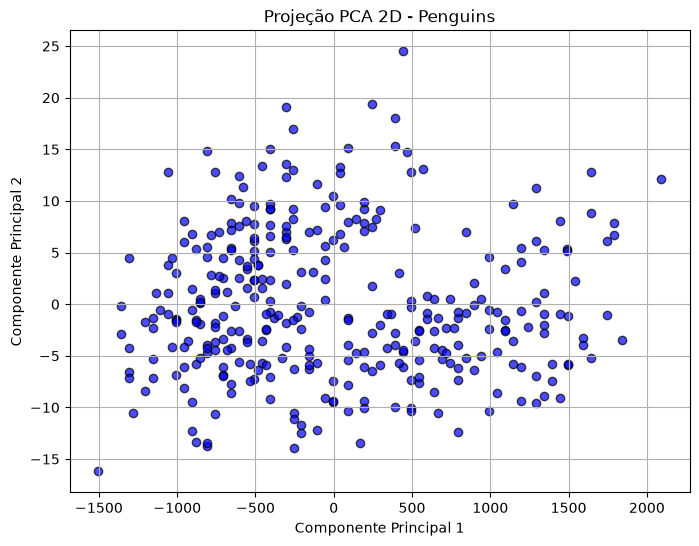

In [8]:
pca_result = fit_pca(X, n_components=2)
X_projected = transform_pca(X, pca_result['components'], pca_result['mean']).detach().cpu().numpy()

plt.figure(figsize=(8, 6))
plt.scatter(X_projected[:, 0], X_projected[:, 1], alpha=0.7, c='blue', edgecolors='k')
plt.title('Projeção PCA 2D - Penguins')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True)
plt.show()

Ainda considerando o item anterior, vamos mostrar a variância explicada obtida quando a dimensão projetada é modificada (1,2,3 ou 4). Lembrando que, se $\lambda_i$ é um autovalor de $S$ (Covariância dos dados) de forma que $\lambda_i \le \lambda_j$ para $i \le j$. Então a variância explicada da projeção em $D$ dimensões é dada por:
$$
    \text{Variância Explicada} = \frac{\sum_{i=1}^D \lambda_i}{\sum_{j=1}^M \lambda_j}
$$

In [9]:
dimensions = [1, 2, 3, 4]

variances = []
for dim in dimensions:
    result = fit_pca(X, n_components=dim)
    variances.append(result['explained_variance'].cpu().numpy())

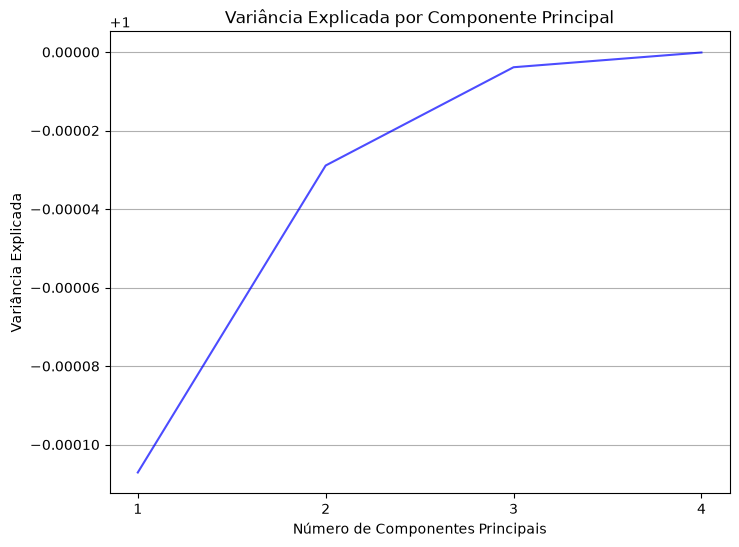

In [10]:
plt.figure(figsize=(8, 6))
plt.plot(dimensions, variances, color='blue', alpha=0.7)
plt.title('Variância Explicada por Componente Principal')
plt.xlabel('Número de Componentes Principais')
plt.ylabel('Variância Explicada')
plt.xticks(dimensions)
plt.grid(axis='y')
plt.show()